<a href="https://colab.research.google.com/github/Atikahdr/ElevvoML_MovieLens_SVD/blob/main/Movie_Lens.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#!pip uninstall -y numpy
#!pip install numpy==1.26.4
#!pip install scikit-surprise --no-cache-dir

In [ ]:
! pip install surprise

# 1. Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 2. Connect G-Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# 3. Load Dataset

In [ ]:
# Rating
ratings = pd.read_csv("/content/drive/MyDrive/Data Enthusiast Project/Elevvo Internship - ML/MovieLens/u.data", sep='\t',
                      names=['user_id','item_id','rating','timestamp'])

ratings.head()

,user_id,item_id,rating,timestamp
0,196,242,3,881250949
1,186,302,3,891717742
2,22,377,1,878887116
3,244,51,2,880606923
4,166,346,1,886397596


In [ ]:
# User
users = pd.read_csv("/content/drive/MyDrive/Data Enthusiast Project/Elevvo Internship - ML/MovieLens/u.user", sep='|',
                    names=['user_id', 'age', 'gender', 'occupation', 'zip'])

users.head()

,user_id,age,gender,occupation,zip
0,1,24,M,technician,85711
1,2,53,F,other,94043
2,3,23,M,writer,32067
3,4,24,M,technician,43537
4,5,33,F,other,15213


In [ ]:
# Movies
movies = pd.read_csv("/content/drive/MyDrive/Data Enthusiast Project/Elevvo Internship - ML/MovieLens/u.item",
                     sep='|', encoding='latin-1', header=None)

movies = movies[[0, 1]]
movies.columns = ['item_id', 'title']

movies.head()

,item_id,title
0,1,Toy Story (1995)
1,2,GoldenEye (1995)
2,3,Four Rooms (1995)
3,4,Get Shorty (1995)
4,5,Copycat (1995)


In [ ]:
movies['item_id'].nunique()

1682

In [ ]:
# Overview Data
print("Ratings shape:", ratings.shape)
print("Users shape:", users.shape)
print("Movies shape:", movies.shape)

Ratings shape: (100000, 4)
Users shape: (943, 5)
Movies shape: (1682, 2)


In [ ]:
# Check Missing Value
print(f"Missing values in ratings: {ratings.isnull().sum().sum()}")
print(f"Missing values in users: {users.isnull().sum().sum()}")
print(f"Missing values in movies: {movies.isnull().sum().sum()}")

Missing values in ratings: 0
Missing values in users: 0
Missing values in movies: 0


# 4. Cleaning Data

In [ ]:
data_lens = ratings.merge(users, on='user_id')
data_lens = data_lens.merge(movies, on='item_id')

data_lens.head()

,user_id,item_id,rating,timestamp,age,gender,occupation,zip,title
0,196,242,3,881250949,49,M,writer,55105,Kolya (1996)
1,186,302,3,891717742,39,F,executive,00000,L.A. Confidential (1997)
2,22,377,1,878887116,25,M,writer,40206,Heavyweights (1994)
3,244,51,2,880606923,28,M,technician,80525,Legends of the Fall (1994)
4,166,346,1,886397596,47,M,educator,55113,Jackie Brown (1997)


# 5. Explaratory Data Analysis (EDA)

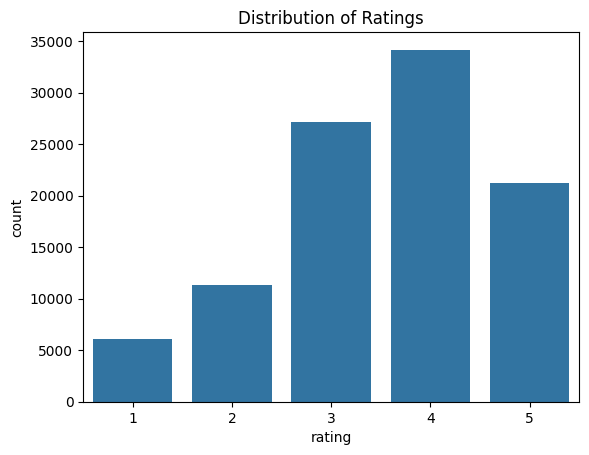

In [ ]:
# Distribution of Ratings
sns.countplot(x="rating", data=ratings)
plt.title("Distribution of Ratings")
plt.show()

In [ ]:
# Most Rated Movies
top_movies = ratings['item_id'].value_counts().head()
top_movies

,count
item_id,
50,583
258,509
100,508
181,507
294,485


In [ ]:
# Most Rates Movies
top_movies = ratings.groupby('item_id')['rating'].count().sort_values(ascending=False).head(10)
top_movies = top_movies.reset_index().merge(movies, on='item_id')

top_movies

,item_id,rating,title
0,50,583,Star Wars (1977)
1,258,509,Contact (1997)
2,100,508,Fargo (1996)
3,181,507,Return of the Jedi (1983)
4,294,485,Liar Liar (1997)
5,286,481,"English Patient, The (1996)"
6,288,478,Scream (1996)
7,1,452,Toy Story (1995)
8,300,431,Air Force One (1997)
9,121,429,Independence Day (ID4) (1996)


In [ ]:
# Sparsity Check
n_users = ratings.user_id.nunique()
n_items = ratings.item_id.nunique()

sparsity = 1 - len(ratings) / (n_users * n_items)
print(f"Sparsity: {sparsity:.2%}")

Sparsity: 93.70%


# 6. Train - Test Split

In [ ]:
from sklearn.model_selection import train_test_split

# Split Data
train_df, test_df = train_test_split(
    ratings,
    test_size=0.2,
    random_state=42
)

# 7. Build User - Item Matrix

In [ ]:
train_matrix = train_df.pivot_table(
    index='user_id',
    columns='item_id',
    values='rating').fillna(0)

test_matrix = test_df.pivot_table(
    index='user_id',
    columns='item_id',
    values='rating').fillna(0)

train_matrix, test_matrix = train_matrix.align(
    test_matrix,
    fill_value=0
)

# 8. User - Based CF Model

In [ ]:
from sklearn.metrics.pairwise import  cosine_similarity

# User similarity
user_similarity = cosine_similarity(train_matrix)
user_similarity_df = pd.DataFrame(
    user_similarity,
    index=train_matrix.index,
    columns=train_matrix.index
)

def predict_user_cf(train_matrix, similarity, k=50):

    pred = np.zeros(train_matrix.shape)

    for i in range(train_matrix.shape[0]):
        sim_scores = similarity.iloc[i].values
        top_k_users = np.argsort(sim_scores)[::-1][1:k+1]

        for j in range(train_matrix.shape[1]):
            numerator = np.dot(sim_scores[top_k_users],
                               train_matrix.iloc[top_k_users, j])
            denominator = np.sum(np.abs(sim_scores[top_k_users]))

            if denominator != 0:
                pred[i, j] = numerator / denominator

    return pd.DataFrame(pred,
                        index=train_matrix.index,
                        columns=train_matrix.columns)

user_cf_predictions = predict_user_cf(train_matrix, user_similarity_df, k=50)

# 9. Item - Based CF Model

In [ ]:
item_similarity = cosine_similarity(train_matrix.T)
item_similarity_df = pd.DataFrame(
    item_similarity,
    index=train_matrix.columns,
    columns=train_matrix.columns
)

def predict_item_cf(train_matrix, similarity, k=50):

    pred =np.zeros(train_matrix.shape)

    for i in range(train_matrix.shape[0]):
        for j in range(train_matrix.shape[1]):

            sim_scores = similarity.iloc[j].values
            top_k_items = np.argsort(sim_scores)[::-1][1:k+1]

            numerator = np.dot(sim_scores[top_k_items],
                               train_matrix.iloc[i, top_k_items])
            denominator = np.sum(np.abs(sim_scores[top_k_items]))

            if denominator != 0:
                pred[i, j] = numerator / denominator

    return pd.DataFrame(pred,
                        index=train_matrix.index,
                        columns=train_matrix.columns)

item_cf_predictions = predict_item_cf(train_matrix, item_similarity_df, k=50)

# 10.  Matrix Factorization (SVD - Surprice)

In [ ]:
from sklearn.metrics import mean_squared_error
from surprise import Dataset, Reader, SVD

def train_svd(train_df, train_matrix, n_factors):

    reader = Reader(rating_scale=(1,5))
    data = Dataset.load_from_df(
        train_df[['user_id', 'item_id', 'rating']],
        reader
    )

    trainset = data.build_full_trainset()

    model = SVD(n_factors=n_factors, random_state=42)
    model.fit(trainset)

    pred_matrix = np.zeros(train_matrix.shape)

    for i, user in enumerate(train_matrix.index):
        for j, item in enumerate(train_matrix.columns):
            pred_matrix[i, j] = model.predict(user, item).est

    return pd.DataFrame(pred_matrix,
                        index=train_matrix.index,
                        columns=train_matrix.columns)

svd_models = {}
for k in [20, 50, 100]:
    svd_models[k] = train_svd(train_df, train_matrix, k)

# Evaluation Metrics

In [ ]:
def precision_at_k(train_matrix, test_matrix, predictions, k=10, threshold=4):

    precisions = []

    for user in train_matrix.index:

        test_ratings = test_matrix.loc[user].values
        train_ratings = train_matrix.loc[user].values
        user_preds = predictions.loc[user].values.copy()

        relevant =set(np.where(test_ratings >= threshold)[0])
        if len(relevant) == 0:
            continue

        train_rated = np.where(train_ratings > 0)[0]
        user_preds[train_rated] = -np.inf

        top_k = set(np.argsort(user_preds)[::-1][:k])
        hits = len(top_k & relevant)

        precisions.append(hits / k)

    return np.mean(precisions) if precisions else 0

def recall_at_k(train_matrix, test_matrix, predictions, k=10, threshold=4):

    recalls = []

    for user in train_matrix.index:

        test_ratings = test_matrix.loc[user].values
        train_ratings = train_matrix.loc[user].values
        user_preds = predictions.loc[user].values.copy()

        relevant = set(np.where(test_ratings >= threshold)[0])
        if len(relevant) == 0:
            continue

        train_rated = np.where(train_ratings > 0)[0]
        user_preds[train_rated] = -np.inf

        top_k = set(np.argsort(user_preds)[::-1][:k])
        hits = len(top_k & relevant)

        recalls.append(hits / len(relevant))

    return np.mean(recalls) if recalls else 0

def rmse_at_k(train_matrix, test_matrix, predictions, k=10):

    rmse_sum = 0
    rmse_count = 0

    for user in train_matrix.index:

        test_ratings = test_matrix.loc[user].values
        train_ratings = train_matrix.loc[user].values
        user_preds = predictions.loc[user].values.copy()

        train_rated = np.where(train_ratings > 0)[0]
        user_preds[train_rated] = -np.inf

        top_k = np.argsort(user_preds)[::-1][:k]

        for item_idx in top_k:
            if test_ratings[item_idx] > 0:
                error = test_ratings[item_idx] - predictions.loc[user].values[item_idx]
                rmse_sum += error ** 2
                rmse_count += 1

    if rmse_count == 0:
        return 0.0

    return np.sqrt(rmse_sum / rmse_count)

def rmse_full(test_matrix, predictions):

    mask = test_matrix.values > 0
    return np.sqrt(
        mean_squared_error(
            test_matrix.values[mask],
            predictions.values[mask]
        )
    )

# Evaluate All Models

In [ ]:
models_dict = {
    "User-Based CF (k=50)": user_cf_predictions,
    "Item-Based CF (k=50)": item_cf_predictions,
}

for k, matrix in svd_models.items():
    models_dict[f"SVD (k={k})"] = matrix

COMPREHENSIVE MODEL EVALUATION

In [ ]:
print('COMPREHENSIVE MODEL EVALUATION')
print('-' * 30)

comparison_results = []

for model_name, preds in models_dict.items():

    p5 = precision_at_k(train_matrix, test_matrix, preds, k=5)
    p10 = precision_at_k(train_matrix, test_matrix, preds, k=10)
    p20 = precision_at_k(train_matrix, test_matrix, preds, k=20)

    r10 = recall_at_k(train_matrix, test_matrix, preds, k=10)

    rmse10 = rmse_at_k(train_matrix, test_matrix, preds, k=10)
    rmse_full_score = rmse_full(test_matrix, preds)

    comparison_results.append([
        model_name,
        p5, p10, p20,
        r10,
        rmse10,
        rmse_full_score
    ])

comparison_df = pd.DataFrame(
    comparison_results,
    columns=[
        'Model',
        'P@5',
        'P@10',
        'P@20',
        'R@10',
        'RMSE@10',
        'RMSE_Full'
    ]
)

# Best Model
best_model_row = comparison_df.loc[comparison_df['P@10'].idxmin()]
best_model_name = best_model_row['Model']
best_precision = best_model_row['P@10']

print(comparison_df.sort_values('RMSE_Full').to_string(index=False))

print(f"\n🏆 BEST MODEL BASED ON Precision@10: {best_model_name}")
print(f"   Precision@10 Score: {best_precision:.4f}")

COMPREHENSIVE MODEL EVALUATION
------------------------------
               Model      P@5     P@10     P@20     R@10  RMSE@10  RMSE_Full
          SVD (k=20) 0.071739 0.067609 0.059946 0.042782 0.739956   0.931124
          SVD (k=50) 0.084565 0.071413 0.061467 0.046289 0.716199   0.931276
         SVD (k=100) 0.083913 0.071848 0.060924 0.053875 0.752289   0.934634
Item-Based CF (k=50) 0.242826 0.210652 0.173750 0.209233 2.199300   2.429128
User-Based CF (k=50) 0.302826 0.242283 0.187609 0.259531 1.750473   2.514166

🏆 BEST MODEL BASED ON Precision@10: SVD (k=20)
   Precision@10 Score: 0.0676


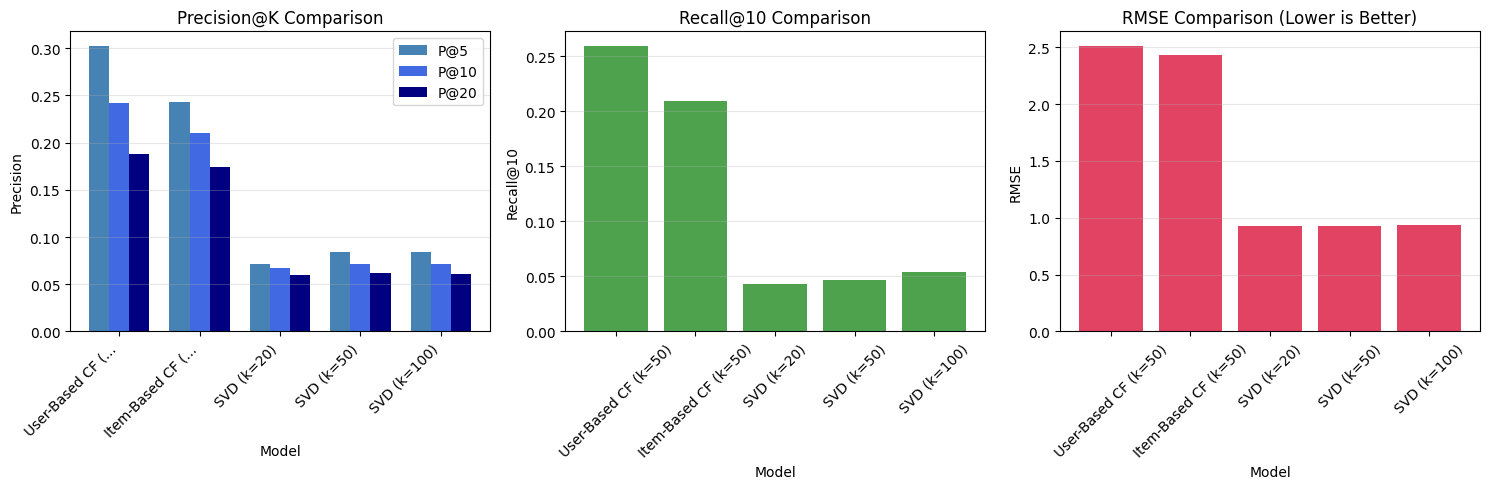

In [ ]:
# Visualize comparison
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Precision@K comparison
models = comparison_df['Model'].values
x = np.arange(len(models))
width = 0.25

axes[0].bar(x - width, comparison_df['P@5'], width, label='P@5', color='steelblue')
axes[0].bar(x, comparison_df['P@10'], width, label='P@10', color='royalblue')
axes[0].bar(x + width, comparison_df['P@20'], width, label='P@20', color='navy')
axes[0].set_xlabel('Model')
axes[0].set_ylabel('Precision')
axes[0].set_title('Precision@K Comparison')
axes[0].set_xticks(x)
axes[0].set_xticklabels([m[:15]+'...' if len(m)>15 else m for m in models], rotation=45, ha='right')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# Recall@10 comparison
axes[1].bar(models, comparison_df['R@10'], color='forestgreen', alpha=0.8)
axes[1].set_xlabel('Model')
axes[1].set_ylabel('Recall@10')
axes[1].set_title('Recall@10 Comparison')
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(axis='y', alpha=0.3)

# RMSE comparison
axes[2].bar(models, comparison_df['RMSE_Full'], color='crimson', alpha=0.8)
axes[2].set_xlabel('Model')
axes[2].set_ylabel('RMSE')
axes[2].set_title('RMSE Comparison (Lower is Better)')
axes[2].tick_params(axis='x', rotation=45)
axes[2].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# Top-N Recommendation Generation

In [ ]:
movie_id_to_title = dict(zip(movies['item_id'], movies['title']))

In [ ]:
# Show User Profile
def show_user_profile(user_id, train_matrix, n_show=5):

    if user_id not in train_matrix.index:
        print("User not found!")
        return

    user_ratings = train_matrix.loc[user_id]
    rated_movies = user_ratings[user_ratings > 0]

    print(f"USER {user_id} PROFILE\n")

    print(f"Total Movies Rated: {len(rated_movies)}")
    print(f"Average Rating: {rated_movies.mean():.2f}")

    print("\nTop Rated Movies:")
    print("-" * 30)

    top_movies = rated_movies.sort_values(ascending=False).head(n_show)

    for i, (item_id, rating) in enumerate(top_movies.items(), 1):
        title = movie_id_to_title.get(item_id, f"Movie_{item_id}")
        print(f"{i:2d}. {title[:45]:<45} | Rating: {rating:.0f}")

In [ ]:
def generate_recommendations(user_id, train_matrix, predicted_ratings,
                             n_recommendations=10):

    if user_id not in train_matrix.index:
        print("User not found!")
        return []

    # Film yang sudah dirating
    rated_mask = train_matrix.loc[user_id] > 0

    # Prediksi user
    user_preds = predicted_ratings.loc[user_id].copy()

    # Exclude film yang sudah ditonton
    user_preds[rated_mask] = -np.inf

    # Ambil Top-N
    top_n = user_preds.sort_values(ascending=False).head(n_recommendations)

    recommendations = []

    for rank, (item_id, pred_rating) in enumerate(top_n.items(), 1):
        title = movie_id_to_title.get(item_id, f"Movie_{item_id}")

        recommendations.append({
            "Rank": rank,
            "Item_ID": item_id,
            "Title": title,
            "Predicted_Rating": round(pred_rating, 2)
        })

    return pd.DataFrame(recommendations)

In [ ]:
# Recommend For User
def recommend_for_user(user_id, train_matrix, predicted_ratings,
                       n_recommendations=10):

    show_user_profile(user_id, train_matrix)

    recommendations = generate_recommendations(
        user_id, train_matrix, predicted_ratings,
        n_recommendations
    )

    print(f"TOP {n_recommendations} RECOMMENDATIONS\n")

    print(recommendations.to_string(index=False))

    return recommendations

In [ ]:
# Usage Examples
best_predictions = models_dict[best_model_name]
sample_user = train_matrix.index[0]

recommend_for_user(
    user_id=sample_user,
    train_matrix=train_matrix,
    predicted_ratings=best_predictions,
    n_recommendations=10
)

USER 1 PROFILE

Total Movies Rated: 208
Average Rating: 3.69

Top Rated Movies:
------------------------------
 1. Nightmare Before Christmas, The (1993)        | Rating: 5
 2. Young Frankenstein (1974)                     | Rating: 5
 3. Nikita (La Femme Nikita) (1990)               | Rating: 5
 4. Lone Star (1996)                              | Rating: 5
 5. Groundhog Day (1993)                          | Rating: 5
TOP 10 RECOMMENDATIONS

 Rank  Item_ID                                                                       Title  Predicted_Rating
    1      318                                                     Schindler's List (1993)              4.76
    2      474 Dr. Strangelove or: How I Learned to Stop Worrying and Love the Bomb (1963)              4.69
    3      357                                      One Flew Over the Cuckoo's Nest (1975)              4.68
    4      515                                                            Boot, Das (1981)              4.65
    5     

,Rank,Item_ID,Title,Predicted_Rating
0,1,318,Schindler's List (1993),4.76
1,2,474,Dr. Strangelove or: How I Learned to Stop Worr...,4.69
2,3,357,One Flew Over the Cuckoo's Nest (1975),4.68
3,4,515,"Boot, Das (1981)",4.65
4,5,657,"Manchurian Candidate, The (1962)",4.63
5,6,408,"Close Shave, A (1995)",4.62
6,7,64,"Shawshank Redemption, The (1994)",4.60
7,8,100,Fargo (1996),4.58
8,9,511,Lawrence of Arabia (1962),4.54
9,10,603,Rear Window (1954),4.53


In [ ]:
# Hit Rate per User
def hit_rate_at_k(user_id, train_matrix, test_matrix,
                  predicted_ratings, k=10, threshold=4):

    if user_id not in train_matrix.index:
        return 0

    # Relevant items in the test set
    test_ratings = test_matrix.loc[user_id]
    relevant_items = test_ratings[test_ratings >= threshold].index

    if len(relevant_items) == 0:
        return 0

    # Exclude films that have been watched on the train
    rated_mask = train_matrix.loc[user_id] > 0
    user_preds = predicted_ratings.loc[user_id].copy()
    user_preds[rated_mask] = -np.inf

    # Top-K
    top_k_items = user_preds.sort_values(ascending=False).head(k).index

    hits = len(set(top_k_items) & set(relevant_items))

    return hits / k

In [ ]:
# Hit Rate all User
def overall_hit_rate(train_matrix, test_matrix, predicted_ratings, k=10, threshold=4):

    scores = []

    for user_id in train_matrix.index:
        score = hit_rate_at_k(user_id, train_matrix, test_matrix, predicted_ratings, k=k, threshold=threshold )
        scores.append(score)

    return np.mean(scores)

# Show Top 10
hit_10 = overall_hit_rate(train_matrix, test_matrix, best_predictions, k=10)
print(f"Overall hit Rate@10: {hit_10:.4f}")

Overall hit Rate@10: 0.0659


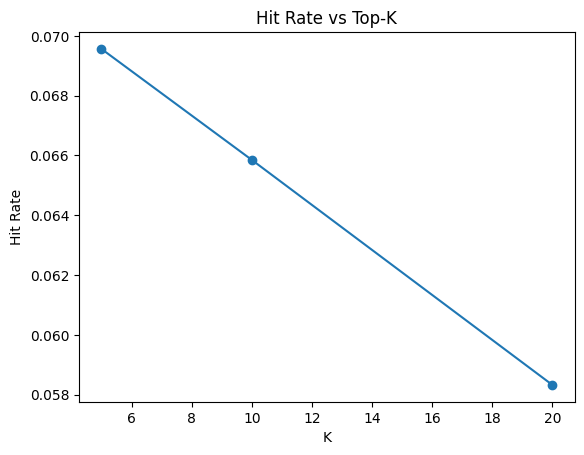

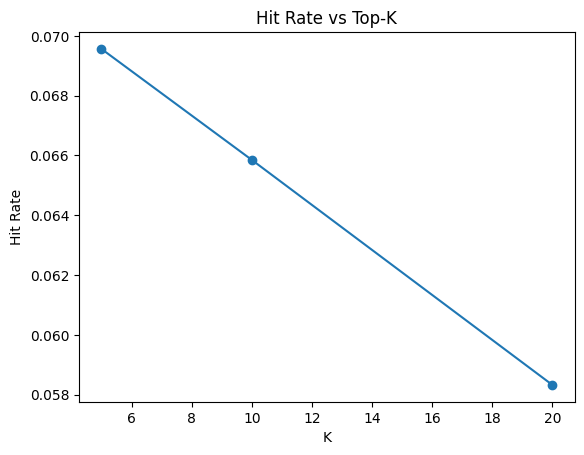

In [ ]:
# Visualization Hit Rate vs k
k_values = [5, 10, 20]
hit_scores = []

for k in k_values:
    score = overall_hit_rate(train_matrix, test_matrix, best_predictions, k=k)
    hit_scores.append(score)

plt.figure()
plt.plot(k_values, hit_scores, marker='o')
plt.xlabel('K')
plt.ylabel('Hit Rate')
plt.title('Hit Rate vs Top-K')
plt.show(())

In [ ]:
# Coverage
def recommendation_coverage(train_matrix, predicted_ratings, k=10):

    recommended_items = set()

    for user_id in train_matrix.index:
        train_rated = train_matrix.loc[user_id] > 0
        user_preds = predicted_ratings.loc[user_id].copy()
        user_preds[train_rated] = -np.inf

        top_k = user_preds.sort_values(ascending=False).head(k).index
        recommended_items.update(top_k)

    total_items = train_matrix.shape[1]

    return len(recommended_items) / total_items

coverage = recommendation_coverage(train_matrix, best_predictions, k=10)

print(f"Recommendation Coverage@10: {coverage:.2%}")

Recommendation Coverage@10: 9.93%


In [ ]:
hit_results = {}

for model_name, preds in models_dict.items():
    score = overall_hit_rate(train_matrix, test_matrix,
                             preds, k=10)
    hit_results[model_name] = score

hit_df = pd.DataFrame({
    "Model": hit_results.keys(),
    "HitRate@10": hit_results.values()
})

print(hit_df.sort_values("HitRate@10", ascending=False))

                  Model  HitRate@10
0  User-Based CF (k=50)    0.236373
1  Item-Based CF (k=50)    0.205514
4           SVD (k=100)    0.069883
3            SVD (k=50)    0.069671
2            SVD (k=20)    0.065854


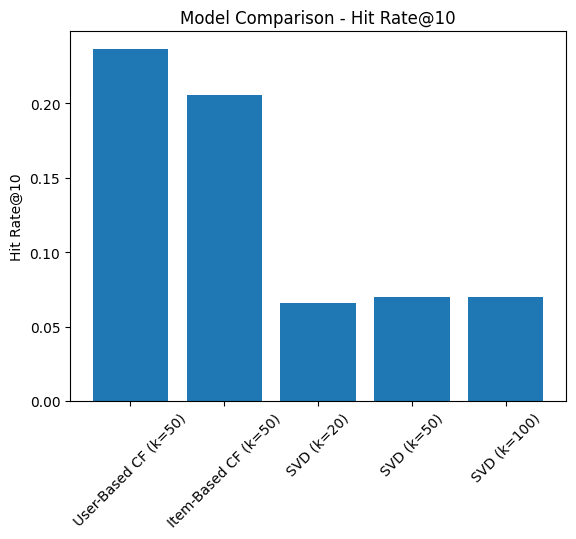

In [ ]:
plt.figure()
plt.bar(hit_df["Model"], hit_df["HitRate@10"])
plt.xticks(rotation=45)
plt.ylabel("Hit Rate@10")
plt.title("Model Comparison - Hit Rate@10")
plt.show()

# Save Model

In [ ]:
import joblib

joblib.dump({
    "best_model_name": best_model_name,
    "best_predictions": best_predictions,
    "train_matrix": train_matrix,
    "movie_mapping": dict(zip(movies['item_id'], movies['title']))
}, "recommender_system1.joblib")

from google.colab import files
files.download("recommender_system1.joblib")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>